##### GoogleNet (Inception) Pre-trained PyTorch Implementation

###### Imports

In [2]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from matplotlib import pyplot as plt
import json

###### Load the Pre-trained Model

In [3]:
model = models.inception_v3(pretrained=True)
model.eval()

/home/bhupen/miniconda3/envs/classification-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bhupen/miniconda3/envs/classification-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

###### Image Transformations

In [4]:
def transform_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((299,299)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.465,0.406],std=[0.229,0.224,0.225])

    ])
    image = Image.open(image_path).convert('RGB')
    return transform(image).unsqueeze(0)

###### Model Inferencing & Loading Class Labels

In [5]:
def predict(image_tansor,model):
    with torch.no_grad():
        outputs = model(image_tansor)
    return torch.nn.functional.softmax(outputs,dim=1)[0]

with open('imagenet_classes.txt') as f:
    lables = [line.strip() for line in f.readlines()]

###### Inferencing & Visualizing Results

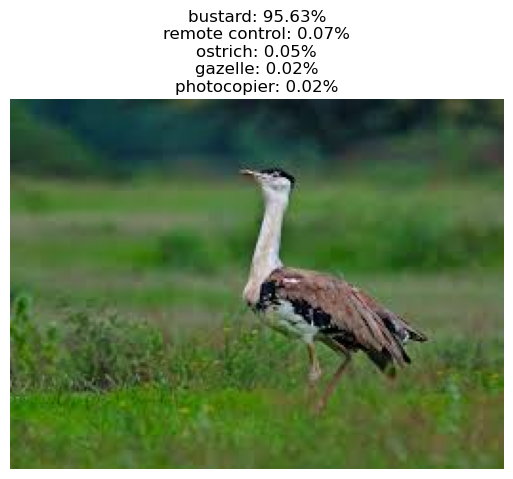

In [6]:
def visualize(image_path,predictions,labels):
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')

    top5_prob,top5_catid = torch.topk(predictions,5)
    top5_labels = [labels[i] for i in top5_catid]

    plt.title('\n'.join([f'{label}: {prob:.2%}' for label,prob in zip(top5_labels,top5_prob)]))
    plt.show()


image_path = 'indian-bustard.jpg'
image_tensor = transform_image(image_path)
predictions = predict(image_tensor,model)
visualize(image_path,predictions,lables)